# Paper 2 — Goal 2 prerequisite
# Freeze the comprehensive Bamboo Passage acoustic representation A — v2.1

This notebook freezes the **clinical acoustic representation A** after the comprehensive Bamboo extraction v2.1 has completed.

It is an outcome-blind measurement/scientific review. It does **not** use:

- ALS/control labels;
- ALSFRS-R bulbar scores;
- Q values or A–Q associations;
- AUC, MAE, feature importance, coefficients, or downstream model performance.

The final role of every implemented feature is decided from:

1. Bamboo Passage task validity;
2. speech-subsystem interpretation;
3. extraction validity and support;
4. empirical distribution/non-degeneracy;
5. direct/algebraic redundancy within A;
6. direct mechanical duplication with Q;
7. measurement maturity.

## Required workflow

### First run
Keep:

`FREEZE_APPROVED = False`

Run the notebook from beginning to end. It creates a detailed review package.

### Scientific review
Complete:

`data/interim/goal2_acoustic_freeze_review_v2/a_registry_review_template.csv`

and save the reviewed file as:

`a_registry_approved.csv`

### Final freeze
Only after explicit feature-by-feature review:

`FREEZE_APPROVED = True`

Restart the kernel and run all cells.

A successful final run writes:

- `data/manifests/a_registry.csv`
- `data/processed/acoustic_features_frozen.csv`
- `data/manifests/a_freeze_manifest.json`

Those files become immutable inputs to Goal 2 and Goal 3.


In [15]:
from __future__ import annotations

import hashlib
import json
import math
import os
from datetime import datetime, timezone
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from scipy import stats
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

FREEZE_APPROVED = True

EXPECTED_ENGINE = "bamboo-acoustic-v2.1.0"
EXPECTED_RECORDINGS = 519
EXPECTED_PARTICIPANTS = 224
A_FREEZE_VERSION = "a-bamboo-v2.1.0"

def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (
            (candidate / "data" / "processed" / "recording_table_phase0.csv").exists()
            and (candidate / "data" / "interim" / "acoustic_features").exists()
        ):
            return candidate
    raise FileNotFoundError("Could not locate Paper 2 clean repository root.")

ROOT = find_project_root()
PROCESSED = ROOT / "data" / "processed"
MANIFESTS = ROOT / "data" / "manifests"
INTERIM = ROOT / "data" / "interim"
ACOUSTIC_DIR = INTERIM / "acoustic_features"

VALUES = ACOUSTIC_DIR / "bamboo_acoustic_features_recording_level.csv"
REGISTRY = ACOUSTIC_DIR / "bamboo_acoustic_feature_registry.csv"
DEFERRED = ACOUSTIC_DIR / "bamboo_alignment_dependent_features_deferred_v2_1.csv"
EXTRACTION_MANIFEST = (
    ROOT / "outputs" / "goal2" / "acoustic_extraction_v2_1"
    / "audit" / "bamboo_acoustic_extraction_manifest.json"
)

REVIEW_DIR = INTERIM / "goal2_acoustic_freeze_review_v2"
FIGURE_DIR = ROOT / "outputs" / "goal2" / "acoustic_freeze_v2" / "figures"

for d in [REVIEW_DIR, FIGURE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Freeze version:", A_FREEZE_VERSION)
print("FREEZE_APPROVED:", FREEZE_APPROVED)


Project root: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code
Freeze version: a-bamboo-v2.1.0
FREEZE_APPROVED: True


## 1. Hard provenance gate

This notebook refuses to freeze the older 20-feature extraction. The canonical acoustic handoff must have been promoted by the successful comprehensive v2.1 extraction.


In [16]:
required_paths = [VALUES, REGISTRY, DEFERRED, EXTRACTION_MANIFEST]
missing = [str(p) for p in required_paths if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Comprehensive acoustic extraction v2.1 has not completed. Missing:\n"
        + "\n".join(missing)
    )

manifest = json.loads(EXTRACTION_MANIFEST.read_text(encoding="utf-8"))

if manifest.get("engine_version") != EXPECTED_ENGINE:
    raise RuntimeError(
        f"Wrong acoustic engine. Expected {EXPECTED_ENGINE}, "
        f"found {manifest.get('engine_version')!r}."
    )

def sha256_file(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()

if sha256_file(VALUES) != manifest["values_sha256"]:
    raise RuntimeError("Canonical acoustic-value hash does not match v2.1 manifest.")

if sha256_file(REGISTRY) != manifest["registry_sha256"]:
    raise RuntimeError("Canonical acoustic-registry hash does not match v2.1 manifest.")

acoustic = pd.read_csv(VALUES, low_memory=False)
registry = pd.read_csv(REGISTRY, low_memory=False)
deferred = pd.read_csv(DEFERRED, low_memory=False)
canonical = pd.read_csv(
    PROCESSED / "recording_table_phase0.csv",
    low_memory=False,
)

for df in [acoustic, canonical]:
    df["logical_recording_id"] = df["logical_recording_id"].astype(str)
    df["participant_id"] = df["participant_id"].astype(str)

assert len(acoustic) == EXPECTED_RECORDINGS
assert acoustic["logical_recording_id"].is_unique
assert acoustic["participant_id"].nunique() == EXPECTED_PARTICIPANTS
assert len(canonical) == EXPECTED_RECORDINGS
assert canonical["logical_recording_id"].is_unique

if set(acoustic["logical_recording_id"]) != set(canonical["logical_recording_id"]):
    raise RuntimeError("Acoustic rows are not the canonical 519 retained recordings.")

assert registry["feature"].is_unique
features = registry["feature"].tolist()

missing_features = [f for f in features if f not in acoustic.columns]
if missing_features:
    raise RuntimeError(f"Registered features missing from value table: {missing_features}")

print("PROVENANCE / COHORT GATE: PASS")
print("Implemented features:", len(features))
print("Deferred high-value features:", len(deferred))
print("Measurement-stage roles:")
display(registry["candidate_role"].value_counts())


PROVENANCE / COHORT GATE: PASS
Implemented features: 38
Deferred high-value features: 6
Measurement-stage roles:


candidate_role
extended_candidate    26
primary_candidate     12
Name: count, dtype: int64

## 2. Registry contract and TASK → FEATURE → SUBSYSTEM audit

Every retained final-A feature must have a complete deterministic measurement contract and an explicit Bamboo Passage clinical/measurement rationale.


In [17]:
required_contract = [
    "feature",
    "acoustic_family",
    "speech_subsystem",
    "definition",
    "unit",
    "extractor_version",
    "validation_status",
    "signal_view",
    "support_rule",
    "unavailable_semantics",
    "transform",
    "clinical_rationale",
    "evidence_basis",
    "candidate_role",
    "q_overlap_note",
    "support_indicator_column",
    "elicitation_task",
]

missing_contract_columns = set(required_contract) - set(registry.columns)
if missing_contract_columns:
    raise KeyError(
        f"Registry missing contract columns: {sorted(missing_contract_columns)}"
    )

def nonblank(series):
    s = series.astype(str).str.strip()
    # "none" is a VALID explicit transform/disposition value.
    # Only genuinely absent/placeholder values are considered blank.
    return series.notna() & s.ne("") & ~s.str.lower().isin(
        {"nan", "unknown", "tbd"}
    )

contract_rows = []
for column in required_contract:
    complete = nonblank(registry[column])
    contract_rows.append({
        "field": column,
        "n_complete": int(complete.sum()),
        "n_missing": int((~complete).sum()),
        "all_complete": bool(complete.all()),
    })

contract_audit = pd.DataFrame(contract_rows)
contract_audit.to_csv(
    REVIEW_DIR / "a_registry_contract_completeness.csv",
    index=False,
)
display(contract_audit)

if not contract_audit["all_complete"].all():
    raise RuntimeError(
        "Candidate registry contract is incomplete. "
        "Resolve extraction-registry fields before feature-role review."
    )

if not registry["elicitation_task"].eq("Bamboo Passage reading").all():
    raise RuntimeError("Non-Bamboo feature found in A candidate registry.")

print("TASK / REGISTRY CONTRACT: PASS")


,field,n_complete,n_missing,all_complete
0,feature,38,0,True
1,acoustic_family,38,0,True
2,speech_subsystem,38,0,True
3,definition,38,0,True
4,unit,38,0,True
5,extractor_version,38,0,True
6,validation_status,38,0,True
7,signal_view,38,0,True
8,support_rule,38,0,True
9,unavailable_semantics,38,0,True


TASK / REGISTRY CONTRACT: PASS


## 3. Outcome-blind support, distribution, and non-degeneracy

No automatic support cutoff is imposed.

The observed distribution is summarized so the Primary-A support rule can be frozen *after* measurement inspection but *before* clinical modeling.


In [18]:
audit_rows = []

for feature in features:
    x = pd.to_numeric(acoustic[feature], errors="coerce")
    finite = x[np.isfinite(x)]

    if len(finite):
        q = np.quantile(finite, [.01, .05, .25, .50, .75, .95, .99])
        variance = float(np.var(finite, ddof=1)) if len(finite) > 1 else np.nan
        iqr = float(q[4] - q[2])
        unique = int(finite.nunique())
        point_mass = float(finite.value_counts().max() / len(finite))
        skew = float(stats.skew(finite, bias=False)) if len(finite) >= 8 else np.nan
    else:
        q = [np.nan] * 7
        variance = iqr = point_mass = skew = np.nan
        unique = 0

    audit_rows.append({
        "feature": feature,
        "acoustic_family": registry.set_index("feature").loc[feature, "acoustic_family"],
        "speech_subsystem": registry.set_index("feature").loc[feature, "speech_subsystem"],
        "candidate_role": registry.set_index("feature").loc[feature, "candidate_role"],
        "n_available": int(len(finite)),
        "availability_fraction": float(len(finite) / len(acoustic)),
        "n_unique_finite": unique,
        "variance": variance,
        "iqr": iqr,
        "skewness": skew,
        "max_point_mass_fraction": point_mass,
        "q01": q[0], "q05": q[1], "q25": q[2],
        "median": q[3], "q75": q[4], "q95": q[5], "q99": q[6],
        "minimum": float(np.min(finite)) if len(finite) else np.nan,
        "maximum": float(np.max(finite)) if len(finite) else np.nan,
        "constant_flag": bool(unique < 2 or (np.isfinite(variance) and variance <= 1e-12)),
    })

feature_audit = pd.DataFrame(audit_rows)
feature_audit.to_csv(
    REVIEW_DIR / "a_feature_outcome_blind_audit.csv",
    index=False,
)

display(
    feature_audit.sort_values(
        ["availability_fraction", "acoustic_family", "feature"]
    )
)

if feature_audit["constant_flag"].any():
    print("WARNING: constant/degenerate candidates require exclusion review.")


,feature,acoustic_family,speech_subsystem,candidate_role,n_available,availability_fraction,n_unique_finite,variance,iqr,skewness,...,q01,q05,q25,median,q75,q95,q99,minimum,maximum,constant_flag
10,bamboo_pause_cv_300ms,timing_fluency,respiratory_prosodic_temporal,extended_candidate,516,0.99422,515,0.114271,0.244359,2.171216,...,0.110601,0.164378,0.240251,0.330239,0.484610,1.303871,1.575754,7.136784e-15,2.528476,False
9,bamboo_pause_iqr_sec_300ms,timing_fluency,respiratory_prosodic_temporal,extended_candidate,516,0.99422,333,0.088134,0.184000,4.906932,...,0.032000,0.064000,0.136000,0.208000,0.320000,0.676000,1.756000,1.776357e-15,3.424000,False
7,bamboo_pause_mean_sec_300ms,timing_fluency,respiratory_prosodic_temporal,primary_candidate,516,0.99422,496,0.116181,0.233257,3.930152,...,0.384600,0.422255,0.544000,0.630857,0.777257,1.269600,2.300367,3.520000e-01,3.744000,False
8,bamboo_pause_median_sec_300ms,timing_fluency,respiratory_prosodic_temporal,extended_candidate,516,0.99422,171,0.060960,0.176000,4.191996,...,0.352000,0.396000,0.496000,0.576000,0.672000,0.989000,1.462400,3.520000e-01,2.816000,False
15,bamboo_phrase_cv_300ms,timing_fluency,respiratory_prosodic_temporal,primary_candidate,516,0.99422,516,0.042586,0.191612,2.135046,...,0.247344,0.279925,0.364438,0.447470,0.556049,0.920775,1.283377,1.515162e-01,1.822156,False
20,bamboo_phrase_duration_last_minus_first_half_sec,timing_fluency,respiratory_prosodic_temporal,extended_candidate,516,0.99422,466,11.304777,1.540000,-0.281724,...,-10.175200,-3.956000,-1.188000,-0.312000,0.352000,2.016000,10.328000,-3.180800e+01,29.376000,False
14,bamboo_phrase_iqr_sec_300ms,timing_fluency,respiratory_prosodic_temporal,extended_candidate,516,0.99422,475,3.204340,0.994000,3.591062,...,0.640000,0.864000,1.280000,1.700000,2.274000,5.200000,10.742800,4.240000e-01,14.704000,False
22,bamboo_f0_iqr_semitones,phonation_prosody,phonatory_prosodic,primary_candidate,519,1.00000,519,15.182933,4.195453,1.413747,...,1.236549,1.780245,2.706052,3.773439,6.901505,13.514588,16.812410,9.582150e-01,22.141285,False
25,bamboo_f0_last_minus_first_half_semitones,phonation_prosody,phonatory_prosodic,extended_candidate,519,1.00000,519,0.963042,0.736125,2.520381,...,-2.253352,-1.476980,-0.621154,-0.251134,0.114971,0.889518,2.050070,-6.258823e+00,10.307174,False
21,bamboo_f0_median_hz,phonation_prosody,phonatory_prosodic,primary_candidate,519,1.00000,519,1216.901806,51.299520,0.754529,...,102.059508,108.572464,123.455404,142.116324,174.754924,215.247149,247.491811,8.832265e+01,257.321163,False


## 4. Support-indicator integrity

Every registered support indicator must exactly reproduce numerical availability.

The support indicator is retained unchanged during Goal 2 Q→A residualization.


In [19]:
support_rows = []

for row in registry.itertuples(index=False):
    feature = row.feature
    support_column = str(row.support_indicator_column)

    if support_column not in acoustic.columns:
        raise KeyError(
            f"Support indicator {support_column!r} for {feature!r} is missing."
        )

    support = pd.to_numeric(acoustic[support_column], errors="coerce")
    if support.isna().any():
        raise RuntimeError(f"Support indicator {support_column} has missing values.")

    observed_values = set(support.unique())
    if not observed_values.issubset({0, 1, 0.0, 1.0}):
        raise RuntimeError(
            f"Support indicator {support_column} is not binary: {observed_values}"
        )

    availability = pd.to_numeric(
        acoustic[feature], errors="coerce"
    ).notna().astype(int)

    exact = np.array_equal(
        support.astype(int).to_numpy(),
        availability.to_numpy(),
    )

    support_rows.append({
        "feature": feature,
        "support_indicator": support_column,
        "exact_match_to_numeric_availability": exact,
        "support_positive": int(support.sum()),
    })

support_audit = pd.DataFrame(support_rows)
support_audit.to_csv(
    REVIEW_DIR / "a_support_indicator_audit.csv",
    index=False,
)

if not support_audit["exact_match_to_numeric_availability"].all():
    display(
        support_audit.loc[
            ~support_audit["exact_match_to_numeric_availability"]
        ]
    )
    raise RuntimeError("At least one A support indicator is inconsistent.")

print("A SUPPORT INDICATORS: PASS")


A SUPPORT INDICATORS: PASS


## 5. Direct algebraic/construct redundancy map

Some measures are deliberately extracted together so the measurement audit can decide which expression is clearest. They must not all survive into Primary-A merely because ridge regression can tolerate collinearity.

These groups are prespecified from definitions—not from clinical performance.


In [20]:
redundancy_groups = pd.DataFrame([
    {
        "group": "global_completion_rate",
        "features": "bamboo_passage_span_sec | bamboo_nominal_speaking_rate_wpm",
        "relationship": "exact inverse transformation because target word count is fixed",
        "primary_rule": "at most one representation should normally enter Primary-A",
    },
    {
        "group": "articulation_rate_units",
        "features": "bamboo_nominal_articulation_rate_wpm | bamboo_nominal_articulation_rate_syll_per_sec",
        "relationship": "exact positive scalar transformation because fixed target counts share the same articulation-time denominator",
        "primary_rule": "choose one unit/definition for Primary-A",
    },
    {
        "group": "pause_burden",
        "features": "bamboo_total_pause_sec_300ms | bamboo_percent_pause_time_300ms",
        "relationship": "same pause-time numerator; percent additionally normalizes by passage duration",
        "primary_rule": "prefer the clinically conventional normalized construct unless a distinct rationale is documented",
    },
    {
        "group": "pause_typical_duration",
        "features": "bamboo_pause_mean_sec_300ms | bamboo_pause_median_sec_300ms",
        "relationship": "two summaries of the same event-duration distribution",
        "primary_rule": "normally choose one robust/clinically conventional summary",
    },
    {
        "group": "pause_variability",
        "features": "bamboo_pause_iqr_sec_300ms | bamboo_pause_cv_300ms",
        "relationship": "two variability summaries of the same pause-duration distribution",
        "primary_rule": "normally choose at most one for Primary-A",
    },
    {
        "group": "phrase_typical_duration",
        "features": "bamboo_phrase_mean_sec_300ms | bamboo_phrase_median_sec_300ms",
        "relationship": "two summaries of the same phrase-duration distribution",
        "primary_rule": "normally choose one",
    },
    {
        "group": "phrase_variability",
        "features": "bamboo_phrase_iqr_sec_300ms | bamboo_phrase_cv_300ms",
        "relationship": "two variability summaries of the same phrase-duration distribution",
        "primary_rule": "normally choose one",
    },
    {
        "group": "pitch_dispersion",
        "features": "bamboo_f0_iqr_semitones | bamboo_f0_p10_p90_range_semitones",
        "relationship": "two robust dispersion summaries of the same frame-level F0 distribution",
        "primary_rule": "normally choose one for Primary-A",
    },
    {
        "group": "f1_dispersion",
        "features": "bamboo_f1_iqr_hz | bamboo_f1_p10_p90_range_hz",
        "relationship": "two robust dispersion summaries of the same automated F1 track",
        "primary_rule": "Extended-A review; do not retain both without rationale",
    },
    {
        "group": "f2_dispersion",
        "features": "bamboo_f2_iqr_hz | bamboo_f2_p10_p90_range_hz",
        "relationship": "two robust dispersion summaries of the same automated F2 track",
        "primary_rule": "Extended-A review; do not retain both without rationale",
    },
])

redundancy_groups.to_csv(
    REVIEW_DIR / "a_prespecified_redundancy_groups.csv",
    index=False,
)

display(redundancy_groups)


,group,features,relationship,primary_rule
0,global_completion_rate,bamboo_passage_span_sec | bamboo_nominal_speak...,exact inverse transformation because target wo...,at most one representation should normally ent...
1,articulation_rate_units,bamboo_nominal_articulation_rate_wpm | bamboo_...,exact positive scalar transformation because f...,choose one unit/definition for Primary-A
2,pause_burden,bamboo_total_pause_sec_300ms | bamboo_percent_...,same pause-time numerator; percent additionall...,prefer the clinically conventional normalized ...
3,pause_typical_duration,bamboo_pause_mean_sec_300ms | bamboo_pause_med...,two summaries of the same event-duration distr...,normally choose one robust/clinically conventi...
4,pause_variability,bamboo_pause_iqr_sec_300ms | bamboo_pause_cv_3...,two variability summaries of the same pause-du...,normally choose at most one for Primary-A
5,phrase_typical_duration,bamboo_phrase_mean_sec_300ms | bamboo_phrase_m...,two summaries of the same phrase-duration dist...,normally choose one
6,phrase_variability,bamboo_phrase_iqr_sec_300ms | bamboo_phrase_cv...,two variability summaries of the same phrase-d...,normally choose one
7,pitch_dispersion,bamboo_f0_iqr_semitones | bamboo_f0_p10_p90_ra...,two robust dispersion summaries of the same fr...,normally choose one for Primary-A
8,f1_dispersion,bamboo_f1_iqr_hz | bamboo_f1_p10_p90_range_hz,two robust dispersion summaries of the same au...,Extended-A review; do not retain both without ...
9,f2_dispersion,bamboo_f2_iqr_hz | bamboo_f2_p10_p90_range_hz,two robust dispersion summaries of the same au...,Extended-A review; do not retain both without ...


## 6. Empirical A–A redundancy diagnostic

Spearman correlation among A candidates is permitted here only as an **outcome-blind diagnostic**.

A large correlation does not itself justify removal. Pruning must be supported by the measurement definitions/constructs above.


In [21]:
X = acoustic[features].apply(pd.to_numeric, errors="coerce")
corr = X.corr(method="spearman", min_periods=30)

corr.to_csv(
    REVIEW_DIR / "a_candidate_spearman_matrix.csv"
)

pairs = []
for i, a in enumerate(corr.columns):
    for b in corr.columns[i + 1:]:
        rho = corr.loc[a, b]
        if np.isfinite(rho) and abs(rho) >= 0.90:
            pairs.append({
                "feature_a": a,
                "feature_b": b,
                "spearman_rho": float(rho),
                "absolute_rho": float(abs(rho)),
            })

high_corr = pd.DataFrame(pairs)
if len(high_corr):
    high_corr = high_corr.sort_values("absolute_rho", ascending=False)

high_corr.to_csv(
    REVIEW_DIR / "a_high_correlation_pairs_absrho_ge_0p90.csv",
    index=False,
)

print("Outcome-blind |rho| >= .90 pairs:", len(high_corr))
display(high_corr)


Outcome-blind |rho| >= .90 pairs: 16


,feature_a,feature_b,spearman_rho,absolute_rho
9,bamboo_pause_count_300ms,bamboo_phrase_count_300ms,1.000000,1.000000
1,bamboo_passage_span_sec,bamboo_nominal_speaking_rate_wpm,-1.000000,1.000000
14,bamboo_nominal_articulation_rate_wpm,bamboo_nominal_articulation_rate_syll_per_sec,0.999999,0.999999
6,bamboo_primary_speech_support_sec,bamboo_nominal_articulation_rate_syll_per_sec,-0.999136,0.999136
5,bamboo_primary_speech_support_sec,bamboo_nominal_articulation_rate_wpm,-0.999134,0.999134
8,bamboo_primary_speech_fraction,bamboo_percent_pause_time_300ms,-0.992150,0.992150
11,bamboo_pause_rate_per_min_300ms,bamboo_phrase_mean_sec_300ms,-0.975024,0.975024
0,bamboo_passage_span_sec,bamboo_primary_speech_support_sec,0.942111,0.942111
4,bamboo_primary_speech_support_sec,bamboo_nominal_speaking_rate_wpm,-0.942096,0.942096
3,bamboo_passage_span_sec,bamboo_nominal_articulation_rate_syll_per_sec,-0.940973,0.940973


## 7. Q-mechanical-overlap review

This uses names, definitions, signal views and the extractor's explicit Q-overlap notes only.

It does **not** calculate A–Q correlations.

Direct Q duplicates should be excluded before Goal 2. Acquisition-sensitive clinical measures may remain because Goal 2 is explicitly designed to quantify their Q dependence.


In [22]:
Q_TERMS = {
    "QADD": [
        "background noise", "snr", "pause level", "hum",
        "speech-pause level contrast",
    ],
    "QGAIN": [
        "recorded rms", "recording intensity", "recorded level",
        "gain drift", "speech level dbfs",
    ],
    "QREV": [
        "srmr", "reverberation", "echo tail",
    ],
    "QCHAN": [
        "ltas distance", "rolloff", "high-band ratio",
        "spectral centroid", "spectral tilt",
    ],
}

def overlap_hits(row):
    text = " ".join([
        str(row["feature"]),
        str(row["definition"]),
        str(row["clinical_rationale"]),
        str(row["signal_view"]),
    ]).lower()
    hits = []
    for family, terms in Q_TERMS.items():
        if any(term in text for term in terms):
            hits.append(family)
    return ";".join(hits)

q_review = registry.copy()
q_review["automatic_direct_overlap_flag"] = q_review.apply(
    overlap_hits, axis=1
)
q_review["automatic_overlap_review_required"] = (
    q_review["automatic_direct_overlap_flag"].ne("")
)

q_review[
    [
        "feature",
        "acoustic_family",
        "definition",
        "q_overlap_note",
        "automatic_direct_overlap_flag",
        "automatic_overlap_review_required",
    ]
].to_csv(
    REVIEW_DIR / "a_q_mechanical_overlap_review.csv",
    index=False,
)

display(
    q_review.loc[
        q_review["automatic_overlap_review_required"],
        [
            "feature",
            "definition",
            "q_overlap_note",
            "automatic_direct_overlap_flag",
        ],
    ]
)

print(
    "Automatic direct-Q-overlap flags:",
    int(q_review["automatic_overlap_review_required"].sum()),
)


,feature,definition,q_overlap_note,automatic_direct_overlap_flag


Automatic direct-Q-overlap flags: 0


## 8. Deferred-feature ledger

These are not failures. They are scientifically meaningful Bamboo measures that require another frozen measurement layer.

They remain outside A until that prerequisite exists.


In [23]:
display(deferred)

deferred.to_csv(
    REVIEW_DIR / "a_deferred_high_value_features.csv",
    index=False,
)


,feature,speech_subsystem,target_material,scientific_value,required_prerequisite,status
0,bamboo_vowel_articulation_index_bark,articulatory,/i/: easy + Japanese; /u/: bamboo + too; /ɑ/: ...,Corner-vowel centralization / articulatory wor...,Validated word/phone alignment plus vowel-nucl...,deferred_alignment_required
1,bamboo_corner_vowel_duration_mean_sec,articulatory_temporal,"/i/, /u/, /ɑ/ Bamboo target words",Target-vowel temporal articulation measure.,Validated word/phone alignment plus vowel boun...,deferred_alignment_required
2,bamboo_flower_f2_range_hz,articulatory,flower,Diphthong F2 excursion used as a tongue-moveme...,Validated location and segmentation of the wor...,deferred_alignment_required
3,bamboo_canonical_timing_alignment,prosodic_temporal,whole fixed Bamboo transcript,Agreement of observed word/silence boundaries ...,Frozen word-level forced alignment and canonic...,deferred_alignment_required
4,bamboo_text_verified_speaking_rate_wpm,prosodic_temporal,whole fixed Bamboo transcript,"Speaking rate accounting for omissions, insert...",Validated ASR/transcript alignment against Bam...,deferred_alignment_required
5,connected_speech_cpps,phonatory,connected Bamboo speech,Established cepstral voice-quality construct.,Pinned validated CPPS implementation and conne...,deferred_validated_implementation_required


## 9. Build the feature-by-feature scientific review template

The template deliberately does not auto-fill the final role.

Required human/scientific decisions:

- `final_role`: `primary`, `extended`, or `exclude`;
- `final_transform`: e.g. `none`, `log1p`, `asinh`;
- `bamboo_task_approved`: `yes`/`no`;
- `measurement_maturity`: `established`, `validated_internal`, `exploratory`;
- `redundancy_disposition`;
- `q_overlap_disposition`;
- `final_rationale`.

No clinical outcome may be consulted while completing these fields.


In [24]:
review = (
    registry
    .merge(
        feature_audit,
        on=[
            "feature",
            "acoustic_family",
            "speech_subsystem",
            "candidate_role",
        ],
        how="left",
        validate="one_to_one",
    )
)

# Map whether the feature appears in an explicit redundancy group.
feature_to_groups = {}
for row in redundancy_groups.itertuples(index=False):
    for feature in [x.strip() for x in row.features.split("|")]:
        feature_to_groups.setdefault(feature, []).append(row.group)

review["prespecified_redundancy_group"] = review["feature"].map(
    lambda f: ";".join(feature_to_groups.get(f, []))
)

# High-correlation partners are a diagnostic only.
high_corr_partner_map = {}
if len(high_corr):
    for row in high_corr.itertuples(index=False):
        high_corr_partner_map.setdefault(row.feature_a, []).append(
            f"{row.feature_b}:{row.spearman_rho:.3f}"
        )
        high_corr_partner_map.setdefault(row.feature_b, []).append(
            f"{row.feature_a}:{row.spearman_rho:.3f}"
        )

review["high_corr_partners_absrho_ge_0p90"] = review["feature"].map(
    lambda f: ";".join(high_corr_partner_map.get(f, []))
)

q_flag_map = q_review.set_index("feature")[
    "automatic_direct_overlap_flag"
].to_dict()
review["automatic_direct_q_overlap_flag"] = review["feature"].map(q_flag_map)

review["bamboo_task_approved"] = ""
review["measurement_maturity"] = ""
review["redundancy_disposition"] = ""
review["q_overlap_disposition"] = ""
review["final_transform"] = review["transform"].fillna("")
review["final_role"] = ""
review["final_rationale"] = ""
review["reviewer_note"] = ""

review_columns = [
    "feature",
    "acoustic_family",
    "speech_subsystem",
    "definition",
    "unit",
    "clinical_rationale",
    "evidence_basis",
    "validation_status",
    "signal_view",
    "support_rule",
    "unavailable_semantics",
    "candidate_role",
    "n_available",
    "availability_fraction",
    "n_unique_finite",
    "iqr",
    "skewness",
    "max_point_mass_fraction",
    "constant_flag",
    "prespecified_redundancy_group",
    "high_corr_partners_absrho_ge_0p90",
    "q_overlap_note",
    "automatic_direct_q_overlap_flag",
    "support_indicator_column",
    "bamboo_task_approved",
    "measurement_maturity",
    "redundancy_disposition",
    "q_overlap_disposition",
    "final_transform",
    "final_role",
    "final_rationale",
    "reviewer_note",
]

review = review[review_columns]

review_template = REVIEW_DIR / "a_registry_review_template.csv"
review.to_csv(review_template, index=False)

print("Review template:", review_template)
display(review)


Review template: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\data\interim\goal2_acoustic_freeze_review_v2\a_registry_review_template.csv


,feature,acoustic_family,speech_subsystem,definition,unit,clinical_rationale,evidence_basis,validation_status,signal_view,support_rule,...,automatic_direct_q_overlap_flag,support_indicator_column,bamboo_task_approved,measurement_maturity,redundancy_disposition,q_overlap_disposition,final_transform,final_role,final_rationale,reviewer_note
0,bamboo_passage_span_sec,timing_fluency,respiratory_prosodic_temporal,Time from first primary-speech onset to last p...,s,Overall time required to complete the fixed pa...,Bamboo/ALS SPA literature: speaking/articulati...,implemented_from_frozen_primary_speech_segment...,frozen primary_speech intervals,At least one valid primary_speech interval. Di...,...,,bamboo_passage_span_sec__supported,,,,,none,,,
1,bamboo_primary_speech_support_sec,timing_fluency,respiratory_prosodic_temporal,Sum of frozen primary_speech interval durations.,s,Raw segmentation-supported active-speech durat...,Bamboo/ALS SPA literature: speaking/articulati...,implemented_from_frozen_primary_speech_segment...,frozen primary_speech intervals,At least one valid primary_speech interval. Di...,...,,bamboo_primary_speech_support_sec__supported,,,,,none,,,
2,bamboo_primary_speech_fraction,timing_fluency,respiratory_prosodic_temporal,Frozen primary_speech support divided by passa...,proportion,Segmentation-supported speech occupancy across...,Bamboo/ALS SPA literature: speaking/articulati...,implemented_from_frozen_primary_speech_segment...,frozen primary_speech intervals,At least one valid primary_speech interval. Di...,...,,bamboo_primary_speech_fraction__supported,,,,,none,,,
3,bamboo_pause_count_300ms,timing_fluency,respiratory_prosodic_temporal,Number of internal gaps between adjacent prima...,count,Clinically established connected-speech pause ...,Bamboo/ALS SPA literature: speaking/articulati...,implemented_from_frozen_primary_speech_segment...,frozen primary_speech intervals,At least one valid primary_speech interval. Di...,...,,bamboo_pause_count_300ms__supported,,,,,none,,,
4,bamboo_total_pause_sec_300ms,timing_fluency,respiratory_prosodic_temporal,Total duration of qualifying internal pauses o...,s,Cumulative clinically relevant pause burden.,Bamboo/ALS SPA literature: speaking/articulati...,implemented_from_frozen_primary_speech_segment...,frozen primary_speech intervals,At least one valid primary_speech interval. Di...,...,,bamboo_total_pause_sec_300ms__supported,,,,,none,,,
5,bamboo_percent_pause_time_300ms,timing_fluency,respiratory_prosodic_temporal,100 × total duration of internal pauses ≥300 m...,%,Published Bamboo/ALS percent-pause-time constr...,Bamboo/ALS SPA literature: speaking/articulati...,implemented_from_frozen_primary_speech_segment...,frozen primary_speech intervals,At least one valid primary_speech interval. Di...,...,,bamboo_percent_pause_time_300ms__supported,,,,,none,,,
6,bamboo_pause_rate_per_min_300ms,timing_fluency,respiratory_prosodic_temporal,Number of internal pauses ≥300 ms divided by p...,pauses/min,Rate-normalized pause frequency.,Bamboo/ALS SPA literature: speaking/articulati...,implemented_from_frozen_primary_speech_segment...,frozen primary_speech intervals,At least one valid primary_speech interval. Di...,...,,bamboo_pause_rate_per_min_300ms__supported,,,,,none,,,
7,bamboo_pause_mean_sec_300ms,timing_fluency,respiratory_prosodic_temporal,Mean duration of internal pauses ≥300 ms.,s,Published connected-speech pause-duration cons...,Bamboo/ALS SPA literature: speaking/articulati...,implemented_from_frozen_primary_speech_segment...,frozen primary_speech intervals,At least one valid primary_speech interval. Di...,...,,bamboo_pause_mean_sec_300ms__supported,,,,,none,,,
8,bamboo_pause_median_sec_300ms,timing_fluency,respiratory_prosodic_temporal,Median duration of internal pauses ≥300 ms.,s,Robust typical pause duration.,Bamboo/ALS SPA literature: speaking/articulati...,implemented_from_frozen_primary_speech_segment...,frozen primary_speech intervals,At least one valid primary_speech interva

## 10. Outcome-blind recommended A freeze draft

The audit above shows:

- 38/38 implemented candidates are nondegenerate;
- 31/38 are available in all 519 recordings;
- the remaining 7 event-distribution features are available in 516/519 and are missing for a mathematically legitimate reason;
- support indicators reproduce numerical availability exactly;
- no direct mechanical duplicate of Core-Q was identified by the prespecified definition screen;
- the main issue is **within-A redundancy**, especially fixed-text timing variables that are algebraically or nearly deterministically related.

The draft below is therefore based only on:

1. task/scientific validity;
2. measurement maturity;
3. support/nondegeneracy;
4. prespecified redundancy;
5. direct Q-overlap adjudication.

It does **not** use diagnosis, ALSFRS-R, Q values, A–Q correlations, model performance, or feature importance.

### Recommended Primary-A

The recommended Primary-A is deliberately compact and clinically interpretable:

1. `bamboo_nominal_articulation_rate_syll_per_sec`
2. `bamboo_percent_pause_time_300ms`
3. `bamboo_pause_mean_sec_300ms`
4. `bamboo_phrase_mean_sec_300ms`
5. `bamboo_phrase_cv_300ms`
6. `bamboo_f0_iqr_semitones`

This represents:

- articulatory-temporal rate;
- pause burden;
- typical pause duration;
- typical phrase organization;
- phrase-duration variability;
- connected-speech prosodic variability.

The more experimental/global articulatory, phonatory, envelope-rhythm, and within-passage-change measures remain Extended-A.

Exact or near-mechanical restatements are excluded from the final frozen representation where they do not add a distinct measurement construct.


In [25]:
# ------------------------------------------------------------------
# Outcome-blind recommended final A disposition.
# ------------------------------------------------------------------

PRIMARY_RECOMMENDED = {
    "bamboo_nominal_articulation_rate_syll_per_sec",
    "bamboo_percent_pause_time_300ms",
    "bamboo_pause_mean_sec_300ms",
    "bamboo_phrase_mean_sec_300ms",
    "bamboo_phrase_cv_300ms",
    "bamboo_f0_iqr_semitones",
}

# Features excluded because another retained feature gives the same or a
# scientifically preferable expression of the same measurement construct.
EXCLUDE_REDUNDANT = {
    # Fixed-text completion/rate redundancy:
    "bamboo_passage_span_sec",
    "bamboo_nominal_articulation_rate_wpm",

    # Pause distribution duplicate summaries:
    "bamboo_pause_median_sec_300ms",
    "bamboo_pause_iqr_sec_300ms",

    # Phrase count is exactly pause count + 1 for the frozen 300-ms rule:
    "bamboo_phrase_count_300ms",

    # Phrase mean/CV are the retained Primary summaries:
    "bamboo_phrase_median_sec_300ms",
    "bamboo_phrase_iqr_sec_300ms",

    # F0 IQR is the retained robust Primary dispersion statistic:
    "bamboo_f0_p10_p90_range_semitones",

    # Within the automated non-phoneme-aligned formant block, retain the
    # IQR versions in Extended-A and drop the parallel P10-P90 summaries.
    "bamboo_f1_p10_p90_range_hz",
    "bamboo_f2_p10_p90_range_hz",
}

# All other implemented, scientifically interpretable measures remain
# prespecified Extended-A candidates.
all_feature_set = set(review["feature"])

if not PRIMARY_RECOMMENDED.issubset(all_feature_set):
    raise RuntimeError(
        "Recommended Primary-A contains a feature absent from the audited registry."
    )
if not EXCLUDE_REDUNDANT.issubset(all_feature_set):
    raise RuntimeError(
        "Recommended exclusion set contains a feature absent from the audited registry."
    )
if PRIMARY_RECOMMENDED & EXCLUDE_REDUNDANT:
    raise RuntimeError("A feature cannot be both Primary and excluded.")

recommended = review.copy()

recommended["bamboo_task_approved"] = "yes"
recommended["final_transform"] = "none"
recommended["q_overlap_disposition"] = "no_direct_q_duplicate"
recommended["redundancy_disposition"] = "retain_extended_distinct_construct"
recommended["measurement_maturity"] = "validated_internal"
recommended["final_role"] = "extended"
recommended["final_rationale"] = (
    "Scientifically interpretable Bamboo Passage measure retained as "
    "prespecified Extended-A; not promoted from clinical or predictive results."
)

# --------------------------------------------------------------
# Measurement-maturity labels by family/construct.
# --------------------------------------------------------------

established_timing = {
    "bamboo_nominal_articulation_rate_syll_per_sec",
    "bamboo_nominal_speaking_rate_wpm",
    "bamboo_percent_pause_time_300ms",
    "bamboo_pause_count_300ms",
    "bamboo_pause_mean_sec_300ms",
    "bamboo_phrase_mean_sec_300ms",
    "bamboo_phrase_cv_300ms",
}

recommended.loc[
    recommended["feature"].isin(established_timing),
    "measurement_maturity",
] = "established_connected_speech_construct"

exploratory = (
    recommended["feature"].str.contains(
        "last_minus_first_half|envelope_mod|harmonicity",
        regex=True,
    )
)
recommended.loc[
    exploratory,
    "measurement_maturity",
] = "exploratory_validated_internal"

automated_formant = recommended["acoustic_family"].eq(
    "segmental_articulation"
)
recommended.loc[
    automated_formant,
    "measurement_maturity",
] = "extended_automated_global_formant_candidate"

# --------------------------------------------------------------
# Primary-A.
# --------------------------------------------------------------

for feature in PRIMARY_RECOMMENDED:
    recommended.loc[
        recommended["feature"].eq(feature),
        [
            "final_role",
            "redundancy_disposition",
        ],
    ] = [
        "primary",
        "retain_primary_distinct_construct",
    ]

PRIMARY_RATIONALES = {
    "bamboo_nominal_articulation_rate_syll_per_sec":
        "Primary articulatory-temporal rate measure for the fixed Bamboo Passage. "
        "Uses the prespecified target-text syllable count and articulation time "
        "excluding pauses >=300 ms; explicitly interpreted as nominal because "
        "actual produced syllables are not transcript-verified.",

    "bamboo_percent_pause_time_300ms":
        "Primary connected-speech pause-burden measure using the frozen 300-ms "
        "clinical pause definition; normalized by passage duration.",

    "bamboo_pause_mean_sec_300ms":
        "Primary typical pause-duration measure. Mean pause duration is retained "
        "as the prespecified clinically conventional event-duration summary; "
        "parallel median/IQR summaries are not needed in Primary-A.",

    "bamboo_phrase_mean_sec_300ms":
        "Primary phrase/breath-group organization measure using phrases bounded "
        "by qualifying pauses >=300 ms.",

    "bamboo_phrase_cv_300ms":
        "Primary normalized phrase-duration variability measure, complementary "
        "to mean phrase duration and not an algebraic restatement of it.",

    "bamboo_f0_iqr_semitones":
        "Primary robust connected-speech prosodic-variability measure. IQR is "
        "retained instead of the parallel P10-P90 F0 range to avoid redundant "
        "dispersion summaries.",
}

for feature, rationale in PRIMARY_RATIONALES.items():
    recommended.loc[
        recommended["feature"].eq(feature),
        "final_rationale",
    ] = rationale

# --------------------------------------------------------------
# Mechanical/scientific redundancy exclusions.
# --------------------------------------------------------------

for feature in EXCLUDE_REDUNDANT:
    recommended.loc[
        recommended["feature"].eq(feature),
        [
            "final_role",
            "redundancy_disposition",
        ],
    ] = [
        "exclude",
        "exclude_scientific_or_mechanical_redundancy",
    ]

EXCLUSION_RATIONALES = {
    "bamboo_passage_span_sec":
        "Excluded from final A because fixed-text speaking rate is an exact "
        "inverse transformation of passage span; completion time remains "
        "available in the extraction audit but does not add a distinct model input.",

    "bamboo_nominal_articulation_rate_wpm":
        "Excluded because it is an exact positive scalar transformation of the "
        "retained syllables-per-second nominal articulation-rate measure.",

    "bamboo_pause_median_sec_300ms":
        "Excluded to avoid retaining parallel mean and median summaries of the "
        "same qualifying-pause duration distribution.",

    "bamboo_pause_iqr_sec_300ms":
        "Excluded from final A because pause variability is already represented "
        "by the retained pause-CV Extended-A measure; avoids parallel variability summaries.",

    "bamboo_phrase_count_300ms":
        "Excluded because under the frozen rule phrase count equals pause count + 1 "
        "and therefore contains no independent information.",

    "bamboo_phrase_median_sec_300ms":
        "Excluded to avoid parallel mean/median summaries of the same phrase-duration distribution.",

    "bamboo_phrase_iqr_sec_300ms":
        "Excluded because phrase variability is represented by the retained "
        "coefficient of variation; avoids parallel variability summaries.",

    "bamboo_f0_p10_p90_range_semitones":
        "Excluded because Primary-A already contains F0 IQR, another robust "
        "dispersion summary of the same frame-level F0 distribution.",

    "bamboo_f1_p10_p90_range_hz":
        "Excluded because the automated global F1 block retains F1 IQR in "
        "Extended-A; parallel robust range summaries are unnecessary.",

    "bamboo_f2_p10_p90_range_hz":
        "Excluded because the automated global F2 block retains F2 IQR in "
        "Extended-A; parallel robust range summaries are unnecessary.",
}

for feature, rationale in EXCLUSION_RATIONALES.items():
    recommended.loc[
        recommended["feature"].eq(feature),
        "final_rationale",
    ] = rationale

# --------------------------------------------------------------
# Specific Extended-A rationale upgrades.
# --------------------------------------------------------------

EXTENDED_RATIONALES = {
    "bamboo_nominal_speaking_rate_wpm":
        "Established fixed-text global speaking-rate measure retained in Extended-A. "
        "Primary-A uses articulation rate plus pause organization; speaking rate is "
        "strongly determined by overlapping timing constructs.",

    "bamboo_pause_count_300ms":
        "Clinically interpretable pause-frequency descriptor retained in Extended-A; "
        "highly related to other phrase/pause organization measures.",

    "bamboo_total_pause_sec_300ms":
        "Raw cumulative pause burden retained in Extended-A; Primary-A uses the "
        "duration-normalized percent-pause-time construct.",

    "bamboo_pause_rate_per_min_300ms":
        "Rate-normalized pause frequency retained in Extended-A; overlaps strongly "
        "with pause count and phrase-duration organization.",

    "bamboo_pause_cv_300ms":
        "Scale-normalized pause-duration variability retained in Extended-A.",

    "bamboo_primary_speech_support_sec":
        "Segmentation-support descriptor retained in Extended-A. It is useful for "
        "sensitivity analyses but is not identical to SPA articulation time.",

    "bamboo_primary_speech_fraction":
        "Segmentation-supported speech occupancy retained in Extended-A; Primary-A "
        "uses the clinically defined >=300-ms percent-pause-time construct.",

    "bamboo_f0_median_hz":
        "Typical connected-speech F0 retained in Extended-A. It is biologically and "
        "demographically dependent and is not needed to define the Primary prosodic construct.",

    "bamboo_f2_iqr_hz":
        "Automated global F2-dispersion candidate retained only in Extended-A. "
        "It is not treated as an exact replication of manually inspected vocalic F2-IQR.",

    "bamboo_f1_iqr_hz":
        "Automated global F1-dispersion candidate retained only in Extended-A; "
        "phoneme-aligned articulatory measures remain deferred.",

    "bamboo_voiced_frame_fraction":
        "Algorithm-dependent periodic-frame support descriptor retained in Extended-A.",

    "bamboo_harmonicity_median_db":
        "Internally validated connected-speech autocorrelation harmonicity measure "
        "retained in Extended-A pending an external/pinned CPPS implementation.",

    "bamboo_harmonicity_iqr_db":
        "Harmonicity variability retained in Extended-A; voice-quality interpretation "
        "is estimator-dependent.",

    "bamboo_envelope_mod_peak_hz":
        "Normalized connected-speech envelope-rhythm descriptor retained in Extended-A; "
        "more exploratory than the Primary timing/fluency measures.",

    "bamboo_envelope_mod_3_6_fraction":
        "Normalized envelope-modulation descriptor retained in Extended-A as an "
        "exploratory rhythm measure.",

    "bamboo_envelope_mod_below4_fraction":
        "Normalized low-frequency modulation-power descriptor retained in Extended-A. "
        "Its high empirical association with envelope entropy is noted but does not "
        "alone justify outcome-blind removal.",

    "bamboo_envelope_mod_entropy":
        "Normalized modulation-spectrum entropy retained in Extended-A; exploratory "
        "and highly associated with another envelope descriptor, to be treated as sensitivity.",
}

for feature, rationale in EXTENDED_RATIONALES.items():
    if feature in all_feature_set and feature not in EXCLUDE_REDUNDANT:
        recommended.loc[
            recommended["feature"].eq(feature),
            "final_rationale",
        ] = rationale

# All remaining within-passage first/second-half measures stay Extended-A.
within_passage = recommended["feature"].str.contains(
    "last_minus_first_half|slope",
    regex=True,
)
recommended.loc[
    within_passage & ~recommended["feature"].isin(EXCLUDE_REDUNDANT),
    "final_rationale",
] = (
    "Outcome-blind within-passage change measure retained in Extended-A only; "
    "linguistic content differs by passage segment and the construct is more "
    "exploratory than the Primary whole-passage representation."
)

# Every implemented feature has no automatic direct Q duplicate in this audit.
recommended["q_overlap_disposition"] = "no_direct_q_duplicate"

# Explicit transforms, frozen BEFORE clinical modeling.
# Use log1p for selected nonnegative, strongly right-skewed duration/variability
# measures. These choices are based only on the observed outcome-blind distribution.
LOG1P_FEATURES = {
    "bamboo_percent_pause_time_300ms",
    "bamboo_pause_mean_sec_300ms",
    "bamboo_pause_cv_300ms",
    "bamboo_phrase_mean_sec_300ms",
    "bamboo_phrase_cv_300ms",
    "bamboo_f0_iqr_semitones",
    "bamboo_total_pause_sec_300ms",
    "bamboo_pause_count_300ms",
    "bamboo_pause_rate_per_min_300ms",
    "bamboo_primary_speech_support_sec",
}

recommended.loc[
    recommended["feature"].isin(LOG1P_FEATURES),
    "final_transform",
] = "log1p"

# Excluded rows still receive explicit review fields.
recommended.loc[
    recommended["final_role"].eq("exclude"),
    "measurement_maturity",
] = recommended.loc[
    recommended["final_role"].eq("exclude"),
    "measurement_maturity",
].fillna("scientifically_valid_but_redundant")

recommended["reviewer_note"] = (
    "Outcome-blind recommended freeze draft generated from the completed "
    "Bamboo measurement audit; requires explicit user/PI scientific approval "
    "before final freeze."
)

# Hard sanity checks.
assert set(recommended["final_role"]) <= {"primary", "extended", "exclude"}
assert recommended["feature"].is_unique
assert recommended["final_rationale"].astype(str).str.strip().ne("").all()

recommended_path = REVIEW_DIR / "a_registry_recommended_draft.csv"
recommended.to_csv(recommended_path, index=False)

summary = (
    recommended.groupby(
        ["final_role", "acoustic_family"],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "n_features"})
)

print("RECOMMENDED OUTCOME-BLIND A FREEZE DRAFT: WRITTEN")
print("Path:", recommended_path)
print("\nFinal-role totals:")
display(
    recommended["final_role"]
    .value_counts()
    .rename_axis("final_role")
    .reset_index(name="n_features")
)
print("\nRole × family:")
display(summary)

print("\nRecommended Primary-A:")
display(
    recommended.loc[
        recommended["final_role"].eq("primary"),
        [
            "feature",
            "speech_subsystem",
            "final_transform",
            "final_rationale",
        ],
    ]
)

print("\nRecommended exclusions:")
display(
    recommended.loc[
        recommended["final_role"].eq("exclude"),
        [
            "feature",
            "redundancy_disposition",
            "final_rationale",
        ],
    ]
)


RECOMMENDED OUTCOME-BLIND A FREEZE DRAFT: WRITTEN
Path: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\data\interim\goal2_acoustic_freeze_review_v2\a_registry_recommended_draft.csv

Final-role totals:


,final_role,n_features
0,extended,22
1,exclude,10
2,primary,6



Role × family:


,final_role,acoustic_family,n_features
0,exclude,phonation_prosody,1
1,exclude,segmental_articulation,2
2,exclude,timing_fluency,7
3,extended,phonation_prosody,7
4,extended,rhythm_envelope,4
5,extended,segmental_articulation,2
6,extended,timing_fluency,9
7,primary,phonation_prosody,1
8,primary,timing_fluency,5



Recommended Primary-A:


,feature,speech_subsystem,final_transform,final_rationale
5,bamboo_percent_pause_time_300ms,respiratory_prosodic_temporal,log1p,Primary connected-speech pause-burden measure ...
7,bamboo_pause_mean_sec_300ms,respiratory_prosodic_temporal,log1p,Primary typical pause-duration measure. Mean p...
12,bamboo_phrase_mean_sec_300ms,respiratory_prosodic_temporal,log1p,Primary phrase/breath-group organization measu...
15,bamboo_phrase_cv_300ms,respiratory_prosodic_temporal,log1p,Primary normalized phrase-duration variability...
18,bamboo_nominal_articulation_rate_syll_per_sec,articulatory_temporal,none,Primary articulatory-temporal rate measure for...
22,bamboo_f0_iqr_semitones,phonatory_prosodic,log1p,Primary robust connected-speech prosodic-varia...



Recommended exclusions:


,feature,redundancy_disposition,final_rationale
0,bamboo_passage_span_sec,exclude_scientific_or_mechanical_redundancy,Excluded from final A because fixed-text speak...
8,bamboo_pause_median_sec_300ms,exclude_scientific_or_mechanical_redundancy,Excluded to avoid retaining parallel mean and ...
9,bamboo_pause_iqr_sec_300ms,exclude_scientific_or_mechanical_redundancy,Excluded from final A because pause variabilit...
11,bamboo_phrase_count_300ms,exclude_scientific_or_mechanical_redundancy,Excluded because under the frozen rule phrase ...
13,bamboo_phrase_median_sec_300ms,exclude_scientific_or_mechanical_redundancy,Excluded to avoid parallel mean/median summari...
14,bamboo_phrase_iqr_sec_300ms,exclude_scientific_or_mechanical_redundancy,Excluded because phrase variability is represe...
17,bamboo_nominal_articulation_rate_wpm,exclude_scientific_or_mechanical_redundancy,Excluded because it is an exact positive scala...
23,bamboo_f0_p10_p90_range_semitones,exclude_scientific_or_mechanical_redundancy,Excluded because Primary-A already contains F0...
31,bamboo_f1_p10_p90_range_hz,exclude_scientific_or_mechanical_redundancy,Excluded because the automated global F1 block...
33,bamboo_f2_p10_p90_range_hz,exclude_scientific_or_mechanical_redundancy,Excluded because the automated global F2 block...


## 11. Review figures

These figures are outcome-blind and are intended to support measurement review, not clinical inference.


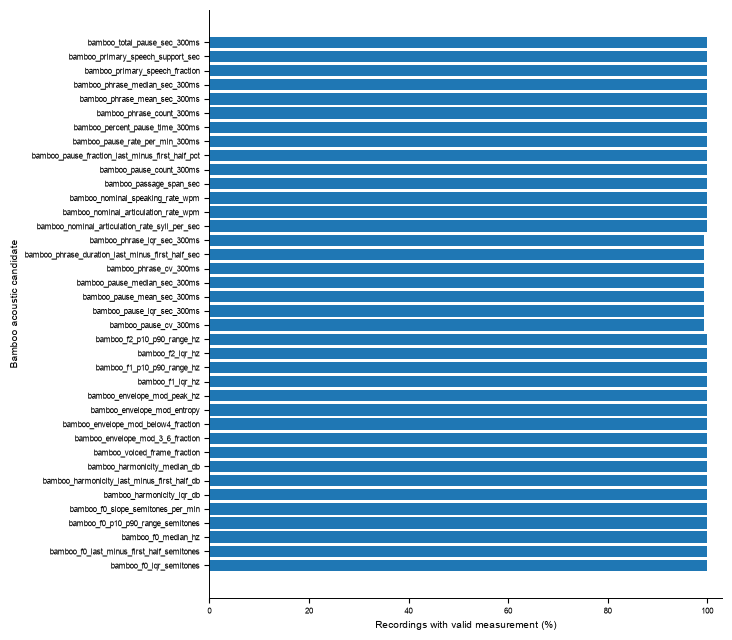

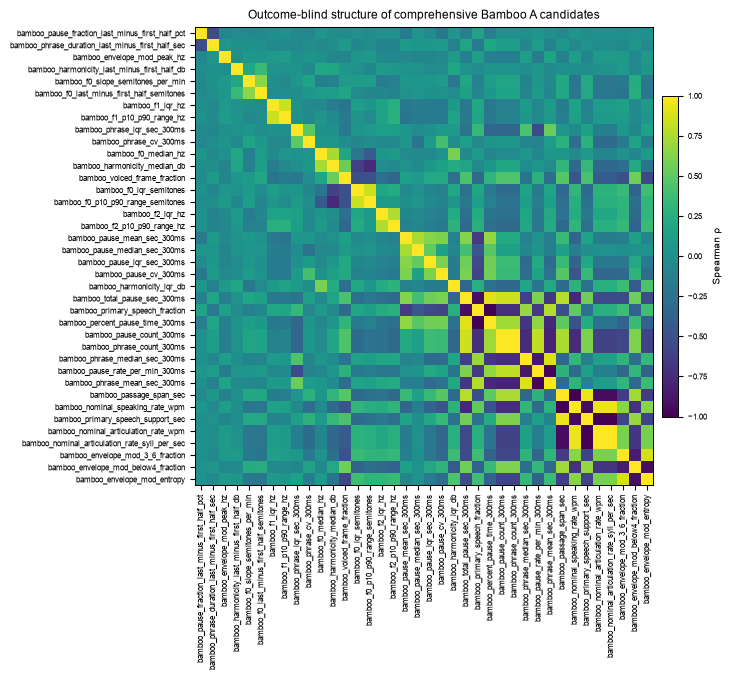

In [26]:
MM_TO_IN = 1 / 25.4
DOUBLE_COLUMN = 183 * MM_TO_IN

mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "axes.linewidth": .7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

def save_fig(fig, name):
    for ext, kwargs in [
        ("pdf", {}),
        ("svg", {}),
        ("png", {"dpi": 600}),
    ]:
        fig.savefig(
            FIGURE_DIR / f"{name}.{ext}",
            bbox_inches="tight",
            **kwargs,
        )
    plt.show()
    plt.close(fig)

# Availability by family
plot = feature_audit.sort_values(
    ["acoustic_family", "availability_fraction", "feature"]
).reset_index(drop=True)

fig, ax = plt.subplots(
    figsize=(DOUBLE_COLUMN, max(130, 4.2 * len(plot)) * MM_TO_IN),
    constrained_layout=True,
)
y = np.arange(len(plot))
ax.barh(y, 100 * plot["availability_fraction"])
ax.set_yticks(y)
ax.set_yticklabels(plot["feature"])
ax.set_xlim(0, 103)
ax.set_xlabel("Recordings with valid measurement (%)")
ax.set_ylabel("Bamboo acoustic candidate")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
save_fig(fig, "A_freeze_v2_feature_availability")

# Clustered correlation
distance = 1 - np.abs(corr.fillna(0).to_numpy())
np.fill_diagonal(distance, 0)
linkage = hierarchy.linkage(squareform(distance, checks=False), method="average")
order = hierarchy.leaves_list(linkage)
ordered = [corr.columns[i] for i in order]
c = corr.loc[ordered, ordered]

fig, ax = plt.subplots(
    figsize=(DOUBLE_COLUMN, DOUBLE_COLUMN),
    constrained_layout=True,
)
im = ax.imshow(c, vmin=-1, vmax=1, interpolation="nearest")
ax.set_xticks(np.arange(len(ordered)))
ax.set_xticklabels(ordered, rotation=90)
ax.set_yticks(np.arange(len(ordered)))
ax.set_yticklabels(ordered)
cb = fig.colorbar(im, ax=ax, fraction=.035, pad=.02)
cb.set_label("Spearman ρ")
ax.set_title("Outcome-blind structure of comprehensive Bamboo A candidates")
save_fig(fig, "A_freeze_v2_candidate_correlation")


## 12. Final freeze gate

`FREEZE_APPROVED=True` does not itself choose features.

The notebook requires an explicit `a_registry_approved.csv` created from the review template.


In [27]:
APPROVED_PATH = REVIEW_DIR / "a_registry_approved.csv"

if not FREEZE_APPROVED:
    status = {
        "created_utc": datetime.now(timezone.utc).isoformat(),
        "status": "REVIEW_REQUIRED",
        "engine_version": EXPECTED_ENGINE,
        "a_freeze_version": A_FREEZE_VERSION,
        "n_implemented_features": int(len(features)),
        "n_deferred_features": int(len(deferred)),
        "review_template": str(review_template.relative_to(ROOT)),
    }
    (REVIEW_DIR / "A_FREEZE_STATUS.json").write_text(
        json.dumps(status, indent=2),
        encoding="utf-8",
    )

    display(Markdown(
        "## A FREEZE: REVIEW REQUIRED\n\n"
        "Do **not** run Goal 2 clinical models yet. Complete the feature-by-feature "
        "`a_registry_review_template.csv`, save it as `a_registry_approved.csv`, "
        "and review the decisions before setting `FREEZE_APPROVED=True`."
    ))

else:
    if not APPROVED_PATH.exists():
        raise FileNotFoundError(
            "FREEZE_APPROVED=True but a_registry_approved.csv is missing."
        )

    approved = pd.read_csv(APPROVED_PATH, low_memory=False)

    required_review_columns = {
        "feature",
        "bamboo_task_approved",
        "measurement_maturity",
        "redundancy_disposition",
        "q_overlap_disposition",
        "final_transform",
        "final_role",
        "final_rationale",
    }
    missing = required_review_columns - set(approved.columns)
    if missing:
        raise KeyError(f"Approved registry missing columns: {sorted(missing)}")

    if approved["feature"].duplicated().any():
        raise RuntimeError("Approved registry has duplicate features.")

    if set(approved["feature"]) != set(features):
        raise RuntimeError(
            "Approved feature identities differ from the audited v2.1 registry."
        )

    approved = registry.merge(
        approved[
            [
                "feature",
                "bamboo_task_approved",
                "measurement_maturity",
                "redundancy_disposition",
                "q_overlap_disposition",
                "final_transform",
                "final_role",
                "final_rationale",
                "reviewer_note",
            ]
        ],
        on="feature",
        how="left",
        validate="one_to_one",
    )

    allowed_roles = {"primary", "extended", "exclude"}
    roles = approved["final_role"].astype(str).str.strip().str.lower()
    if not roles.isin(allowed_roles).all():
        bad = sorted(set(roles) - allowed_roles)
        raise ValueError(f"Invalid/blank final_role values: {bad}")
    approved["final_role"] = roles

    task_approved = approved["bamboo_task_approved"].astype(str).str.strip().str.lower()
    valid_task = task_approved.isin({"yes", "no"})
    if not valid_task.all():
        raise ValueError("bamboo_task_approved must be yes/no for every feature.")
    approved["bamboo_task_approved"] = task_approved

    retained = approved["final_role"].isin({"primary", "extended"})

    if not approved.loc[retained, "bamboo_task_approved"].eq("yes").all():
        bad = approved.loc[
            retained & ~approved["bamboo_task_approved"].eq("yes"),
            "feature",
        ].tolist()
        raise ValueError(f"Retained features not approved for Bamboo: {bad}")

    for column in [
        "measurement_maturity",
        "redundancy_disposition",
        "q_overlap_disposition",
        "final_transform",
        "final_rationale",
    ]:
        if not nonblank(approved.loc[retained, column]).all():
            bad = approved.loc[
                retained & ~nonblank(approved[column]),
                "feature",
            ].tolist()
            raise ValueError(f"Retained features have blank {column}: {bad}")

    # No constant feature can be retained.
    constant_map = feature_audit.set_index("feature")["constant_flag"]
    approved["constant_flag"] = approved["feature"].map(constant_map).fillna(False)
    if (retained & approved["constant_flag"]).any():
        bad = approved.loc[
            retained & approved["constant_flag"], "feature"
        ].tolist()
        raise ValueError(f"Constant features cannot be retained: {bad}")

    # Explicit direct-Q duplicates cannot be retained if review says duplicate.
    if (
        retained
        & approved["q_overlap_disposition"].astype(str).str.lower().eq(
            "exclude_direct_q_duplicate"
        )
    ).any():
        bad = approved.loc[
            retained
            & approved["q_overlap_disposition"].astype(str).str.lower().eq(
                "exclude_direct_q_duplicate"
            ),
            "feature",
        ].tolist()
        raise ValueError(
            "Features marked as direct Q duplicates must have final_role=exclude: "
            f"{bad}"
        )

    # Exact algebraic redundancy: both members may be retained in Extended-A,
    # but both may not be Primary-A.
    exact_primary_pairs = [
        (
            "bamboo_passage_span_sec",
            "bamboo_nominal_speaking_rate_wpm",
        ),
        (
            "bamboo_nominal_articulation_rate_wpm",
            "bamboo_nominal_articulation_rate_syll_per_sec",
        ),
    ]
    primary_set = set(
        approved.loc[approved["final_role"].eq("primary"), "feature"]
    )
    for a, b in exact_primary_pairs:
        if a in primary_set and b in primary_set:
            raise ValueError(
                "Exact algebraic redundancy in Primary-A: "
                f"{a} and {b}. Choose one."
            )

    primary = approved.loc[
        approved["final_role"].eq("primary"), "feature"
    ].tolist()
    extended = approved.loc[
        approved["final_role"].eq("extended"), "feature"
    ].tolist()

    if not primary:
        raise ValueError("Primary-A is empty.")

    retained_features = primary + extended

    support_columns = sorted({
        str(
            registry.set_index("feature").loc[
                feature,
                "support_indicator_column",
            ]
        )
        for feature in retained_features
    })

    frozen_values = acoustic[
        ["logical_recording_id", "participant_id"]
        + retained_features
        + support_columns
    ].copy()

    # Final support check.
    for feature in retained_features:
        support_col = registry.set_index("feature").loc[
            feature, "support_indicator_column"
        ]
        numeric_availability = pd.to_numeric(
            frozen_values[feature], errors="coerce"
        ).notna().astype(int)
        support = pd.to_numeric(
            frozen_values[support_col], errors="coerce"
        ).astype(int)
        if not np.array_equal(numeric_availability.to_numpy(), support.to_numpy()):
            raise RuntimeError(f"Final support mismatch for {feature}.")

    registry_out = approved.copy()
    registry_out["a_freeze_version"] = A_FREEZE_VERSION
    registry_out["extraction_engine"] = EXPECTED_ENGINE

    registry_path = MANIFESTS / "a_registry.csv"
    values_path = PROCESSED / "acoustic_features_frozen.csv"

    # Atomic writes.
    def atomic_csv(df, path):
        temp = path.with_suffix(path.suffix + ".tmp")
        df.to_csv(temp, index=False)
        if temp.stat().st_size == 0:
            raise IOError(f"Empty temporary output: {temp}")
        os.replace(temp, path)

    atomic_csv(registry_out, registry_path)
    atomic_csv(frozen_values, values_path)

    freeze_manifest = {
        "created_utc": datetime.now(timezone.utc).isoformat(),
        "status": "FROZEN",
        "a_freeze_version": A_FREEZE_VERSION,
        "acoustic_extraction_engine": EXPECTED_ENGINE,
        "source_values_sha256": sha256_file(VALUES),
        "source_registry_sha256": sha256_file(REGISTRY),
        "approved_review_sha256": sha256_file(APPROVED_PATH),
        "a_registry_sha256": sha256_file(registry_path),
        "acoustic_features_frozen_sha256": sha256_file(values_path),
        "retained_recordings": int(len(frozen_values)),
        "participants": int(frozen_values["participant_id"].nunique()),
        "n_primary_a": int(len(primary)),
        "n_extended_a": int(len(extended)),
        "n_excluded_implemented": int(
            approved["final_role"].eq("exclude").sum()
        ),
        "n_deferred_alignment_or_validation": int(len(deferred)),
        "primary_a": primary,
        "extended_a": extended,
        "selection_used_clinical_outcomes": False,
        "selection_used_q_values_or_a_q_associations": False,
        "selection_used_predictive_performance": False,
        "used_outcome_blind_a_a_redundancy_diagnostics": True,
    }

    freeze_manifest_path = MANIFESTS / "a_freeze_manifest.json"
    freeze_manifest_path.write_text(
        json.dumps(freeze_manifest, indent=2),
        encoding="utf-8",
    )

    print("A FREEZE: PASS")
    print("Primary-A:", len(primary))
    print("Extended-A:", len(extended))
    print("Excluded implemented:", int(
        approved["final_role"].eq("exclude").sum()
    ))
    print("Deferred:", len(deferred))
    print("Registry:", registry_path)
    print("Values:", values_path)
    print("Manifest:", freeze_manifest_path)


A FREEZE: PASS
Primary-A: 6
Extended-A: 22
Excluded implemented: 10
Deferred: 6
Registry: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\data\manifests\a_registry.csv
Values: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\data\processed\acoustic_features_frozen.csv
Manifest: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\data\manifests\a_freeze_manifest.json


# Next

Do not construct the Goal 2 clinical models until the final cell reports:

`A FREEZE: PASS`

Once A is frozen, Goal 2 can be built against a fixed measurement object:

- Primary-A + support indicators;
- Core-Q from Goal 1;
- same participant split manifest;
- all repeated recordings with participant-normalized training weights;
- Age + A;
- Age + A + Q;
- Age + A-resQ;
- paired participant bootstrap;
- individual prediction shifts;
- within-/between-participant Q dependence of cross-fitted model loss.


In [28]:
import shutil

src = REVIEW_DIR / "a_registry_recommended_draft.csv"
dst = REVIEW_DIR / "a_registry_approved.csv"

shutil.copy2(src, dst)

print("Approved registry created:")
print(dst)

Approved registry created:
C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\data\interim\goal2_acoustic_freeze_review_v2\a_registry_approved.csv
